**How Indicative Are Age and Number of Hours Played on a UBC scientist-run Minecraft Server of a Player's Subscription Status to the game-related newsletter?**

## (1) Introduction:

This project aims to use data collected from a minecraft server run by UBC scientists to answer the following broad question: “What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?” More specifically, we would like to address the following question: “Can age and number of hours played predict whether a player is subscribed to the game-related newsletter?” This will help identify whether age and number of hours are predictive of subscribing to the game-related newsletter. To help answer these questions, we utilized data from the players.csv dataset. This file contains player age, number of hours played, and newsletter subscription status. This dataset also includes 196 observations. This data was collected through a minecraft server set up by a research group in computer science at UBC. A potential problem with it is that it has the subscription status of the player stored as a logical type of data. This will need to be changed to a factor type of data in order to perform KNN classification. In addition, people may lie about their name, gender, and age. Some players also report zero hours of gameplay, but it is unclear whether it is because they are new or simply uninterested in playing. This distinction is important in the context of making predictions. For example, if 18-year-olds normally game a lot, but have few played hours because they only recently joined the study, it could skew the predicted played hours for similar age individuals. In addition, if the "experience" variable is self-reported, then designations may be subjective and unreliable as predictors. Furthermore, age in this context is technically not a quantitative variable, since it is not continuous (technically it is discrete and qualitative), as it is only composed of integer numbers. However, for the purposes of this project, we will consider age as a quantitative variable so we can use KNN classification on the dataset. We have included a small section of the players.csv dataset below to help visualize what the dataset looks like.

## (2) Methods:

## (3) Code and Results:

The players.csv file contains 196 observations, each representing a unique player. 7 variables capture the demographic information and skill level of each player. Many players report zero hours of gameplay, but it is unclear whether it is because they are new or simply uninterested in playing. This distinction is important in the context of making predictions. For example, if 18-year-olds normally game a lot, but have few played hours because they only recently joined the study, it could skew the predicted played hours for similar age individuals.

| Variable Name | Type | Description | No. of Unique Values | Mean | Standard Deviation | Min | Max | Median |
| -------- | ------- | ------- | ------- | ------- | ------- | ------- | ------- | ------- |
| experience | fct (loaded in as chr) | level of experience the player has with gaming | 5 | | | | | |
| subscribe | lgl | whether the player is subscribed to the game's associated newsletter  | 2 | | | | | |
| hashedEmail | chr | player's email encrypted as a code | 196 | | | | | |
| played_hours | dbl | no. of hours the player has played on the Minecraft server | 43 | 5.845918 |28.35734 | 0 | 223.1 | 0.1 |
| name | chr | player's first name | 196 | | | | | |
| gender | fct (loaded in as chr) | player's gender | 7 | | | | | |
| Age | int (loaded in as dbl) | player's age in years | 31 | 20.52062 | 6.174667 | 8 | 50 | 19 |

The `subscribe` variable was converted from a logical to a factor type using `fct_recode()` for proper KNN classification labeling. Additionally, removing observations with `NA` resulted in the loss of only 2 observations, which is unlikely to have a significant impact on the data. The data includes 142 newsletter subscribers and 52 non-subscribers, indicating imbalanced classes for `subscribe`.

In [38]:
library(tidyverse)
library(tidymodels)
library(cowplot)
library(repr)

set.seed(4)
options(repr.plot.width = 14)

players_url <- "https://raw.githubusercontent.com/oo74/DSCI-100-Project/d932a95bab3bbe9a443dcba02939882b0735483f/data/players.csv"
players <- read_csv(players_url) |>
    mutate(subscribe = fct_recode(as_factor(subscribe), Yes = "TRUE", No = "FALSE"))

players |>
    map_df(n_distinct)

players |>
    summarize(mean = mean(played_hours, na.rm = TRUE),
              SD = sd(played_hours, na.rm = TRUE),
              min = min(played_hours, na.rm = TRUE),
              max = max(played_hours, na.rm = TRUE),
              median = median(played_hours, na.rm = TRUE))

players |>
    summarize(mean = mean(Age, na.rm = TRUE),
              SD = sd(Age, na.rm = TRUE),
              min = min(Age, na.rm = TRUE),
              max = max(Age, na.rm = TRUE),
              median = median(Age, na.rm = TRUE))

nrow(players)
players <- drop_na(players)
nrow(players)

players |>
    group_by(subscribe) |>
    summarize(count = n())

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<int>,<int>,<int>,<int>,<int>,<int>,<int>
5,2,196,43,196,7,31


mean,SD,min,max,median
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5.845918,28.35734,0,223.1,0.1


mean,SD,min,max,median
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
20.52062,6.174667,8,50,19


[1] 196

[1] 194

subscribe,count
<fct>,<int>
No,52
Yes,142


To reduce overplotting and enhance density visualization, datapoint opacity was set to 0.6, where higher opacity indicates more overlap. 

Fig. 1 shows no clear linear relationship between hours played and age. Most players are clustered around zero hours, with a few outliers exceeding 150 hours. As seen in Fig. 2, the majority of players are between 15 and 28 years old, with a significant concentration at age 17. Nearly all age groups 17 and older contain non-subscribed players, while those younger are all subscribed. Fig. 3 indicates that most non-subscribed players have low played hours. However, since the majority of all players report low hours and there is limited data for high-hour players, this observation may not imply a direct association between low played hours and the tendency to subscribe.

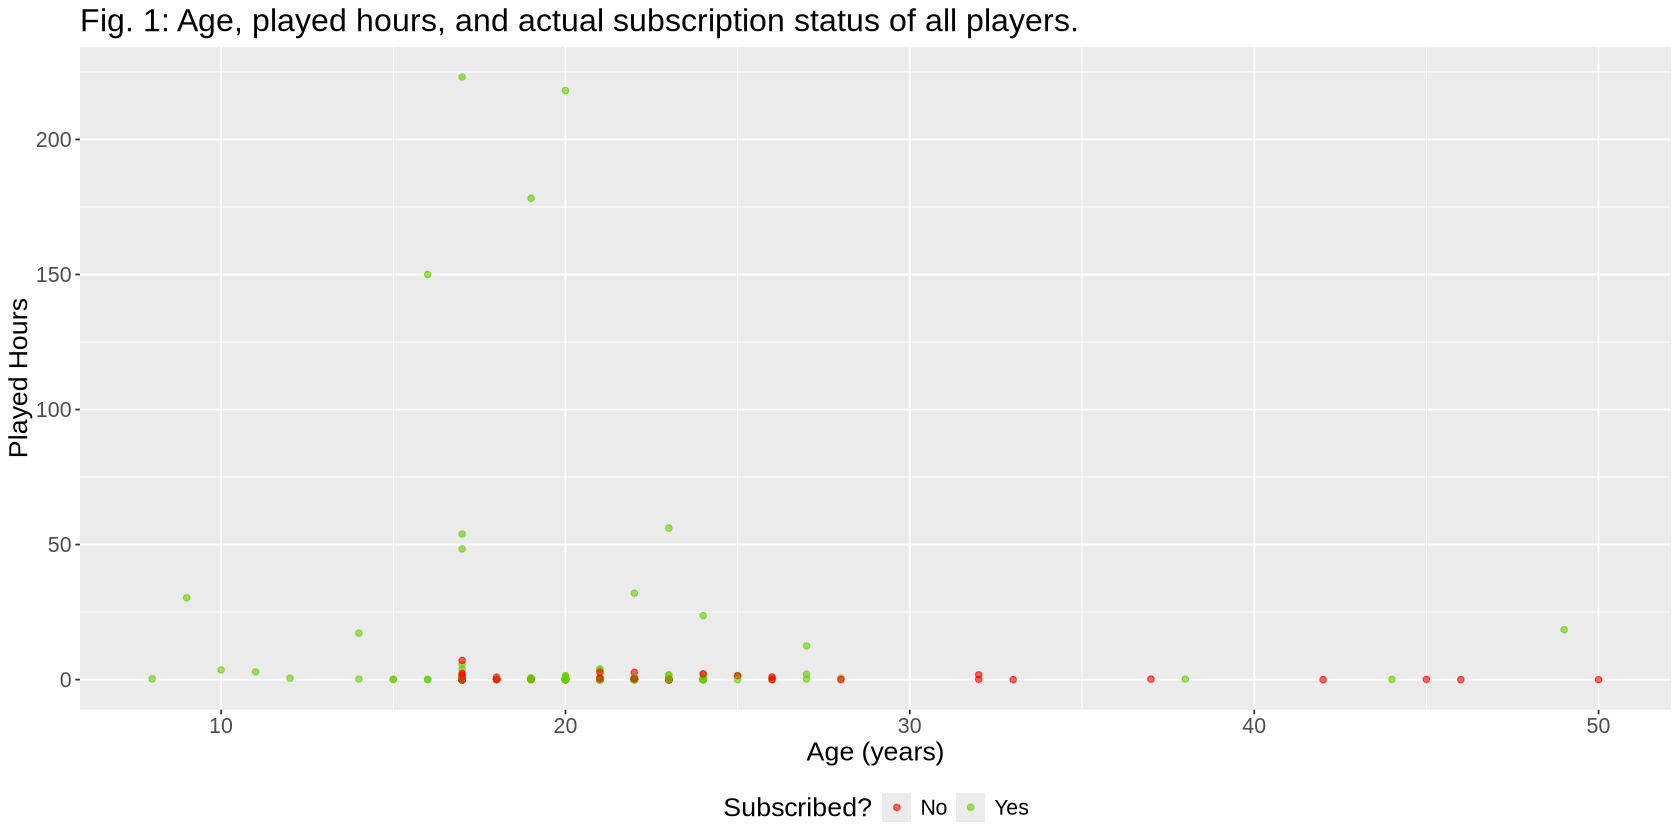

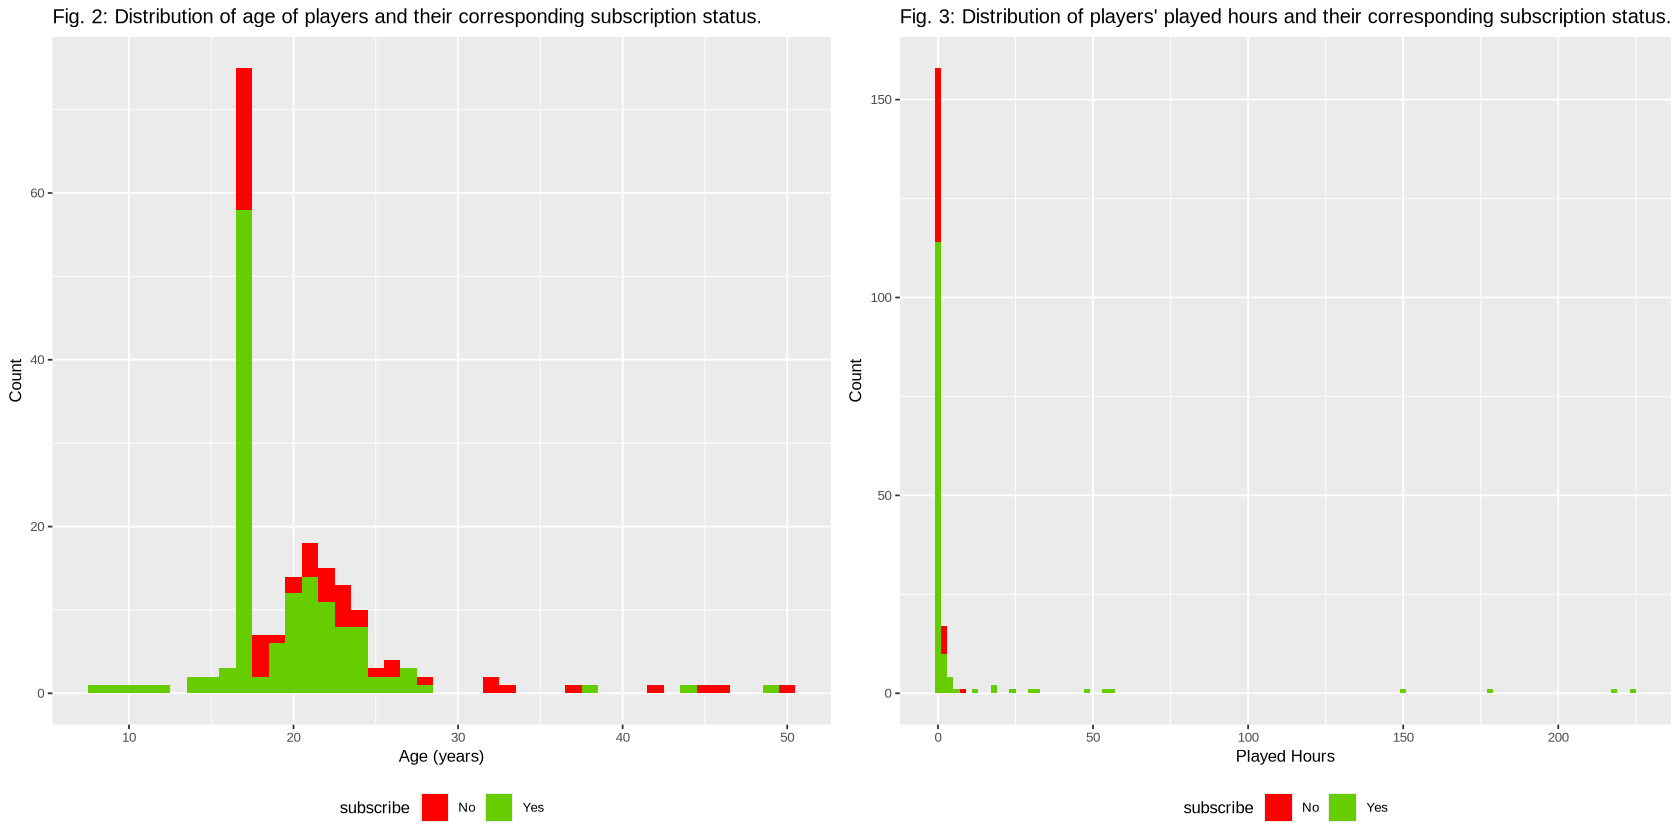

In [34]:
age_hours_plot <- players |>
    ggplot(aes(x = Age, y = played_hours, color = subscribe)) +
    geom_point(alpha = 0.6) +
    labs(x = "Age (years)", y = "Played Hours", title = "Fig. 1: Age, played hours, and actual subscription status of all players.", color = "Subscribed?") +
    theme(text = element_text(size = 16), legend.position = "bottom", legend.direction = "horizontal") +
    scale_color_manual(values = c("red", "chartreuse3"))

age_plot <- players |>
    ggplot(aes(x = Age, fill = subscribe)) +
    geom_histogram(binwidth = 1) +
    labs(x = "Age (years)", y = "Count", title = "Fig. 2: Distribution of age of players and their corresponding subscription status.") +
    theme(text = element_text(size = 10), legend.position = "bottom", legend.direction = "horizontal") +
    scale_fill_manual(values = c("red", "chartreuse3"))

hours_plot <- players |>
    ggplot(aes(x = played_hours, fill = subscribe)) +
    geom_histogram(binwidth = 2) +
    labs(x = "Played Hours", y = "Count", title = "Fig. 3: Distribution of players' played hours and their corresponding subscription status.") +
    theme(text = element_text(size = 10), legend.position = "bottom", legend.direction = "horizontal") +
    scale_fill_manual(values = c("red", "chartreuse3"))


age_hours_plot
plot_grid(age_plot, hours_plot, ncol = 2)

Before modeling, 75% of the data was split into a training set and 25% was split into a testing set. This ensures that the model's performance is evaluated on unseen data rather than on the same examples it was trained on, which can lead to inaccurately high performance metrics and poor classification of new observations if the model simply memorizes the training data instead of learning generalizable patterns. To determine the best K value for the K-nearest neighbors classifier, 5-fold cross-validation was performed on the training set for K values ranging from 1 to 25. The mean accuracies were calculated for each K, and the best K was selected based on the highest accuracy. Any ties among the highest accuracy K values were resolved by selecting the smallest K to improve computational efficiency.

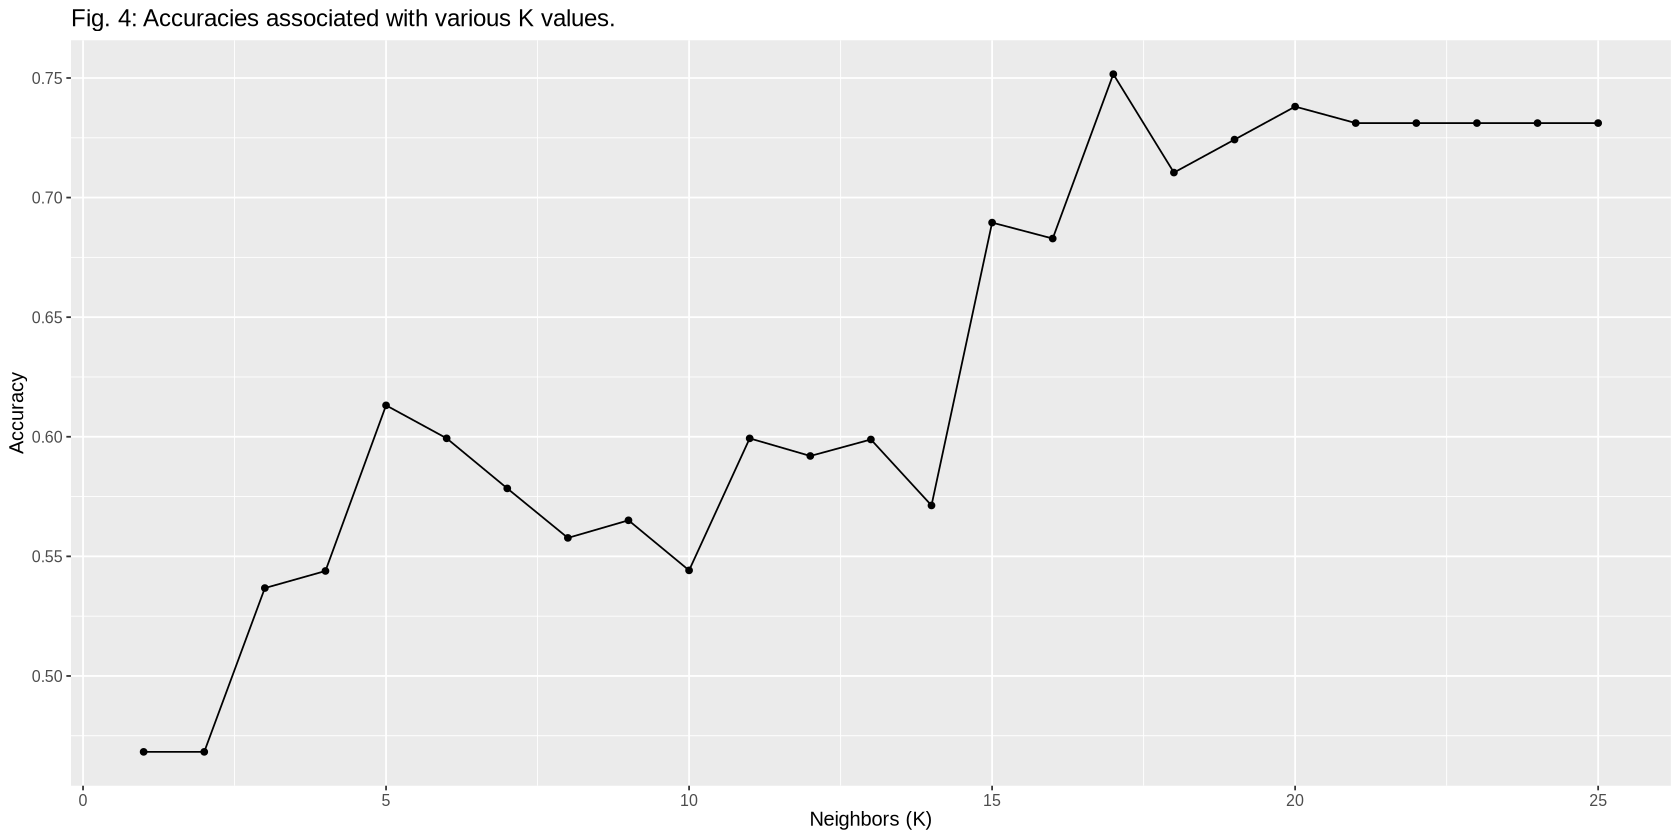

In [40]:
k_vals <- tibble(neighbors = 1:25)

players_split <- initial_split(players, prop = 0.75, strata = subscribe)
players_train <- training(players_split)
players_test <- testing(players_split)

players_recipe <- recipe(subscribe ~ played_hours + Age, data = players_train) |>
    step_center(all_predictors()) |>
    step_scale(all_predictors()) 

players_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
    set_engine("kknn") |>
    set_mode("classification")

vfold_sets <- players_train |>
    vfold_cv(v = 5, strata = subscribe)

k_accuracies <- workflow() |>
    add_recipe(players_recipe) |>
    add_model(players_spec) |>
    tune_grid(resamples = vfold_sets, grid = k_vals) |>
    collect_metrics() |>
    filter(.metric == "accuracy") |>
    mutate(accuracy = mean) |>
    select(neighbors, accuracy)
    
k_accuracies_plot <- k_accuracies |>
    ggplot(aes(x = neighbors, y = accuracy)) +
    geom_point() +
    geom_line() +
    labs(x = "Neighbors (K)", y = "Accuracy", title = "Fig. 4: Accuracies associated with various K values.") +
    theme(text = element_text(size = 12))

best_k <- k_accuracies |>
    slice_max(accuracy) |>
    slice_min(neighbors) |>
    pull(neighbors)

k_accuracies_plot

With the optimal K determined, a new model was built using that K to predict outcomes on the test set. Since initial visualizations revealed that most observations reported under 2.5 player hours, the y-axis was capped at 2.5 to spread out the majority of the datapoints and enhance clarity.

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


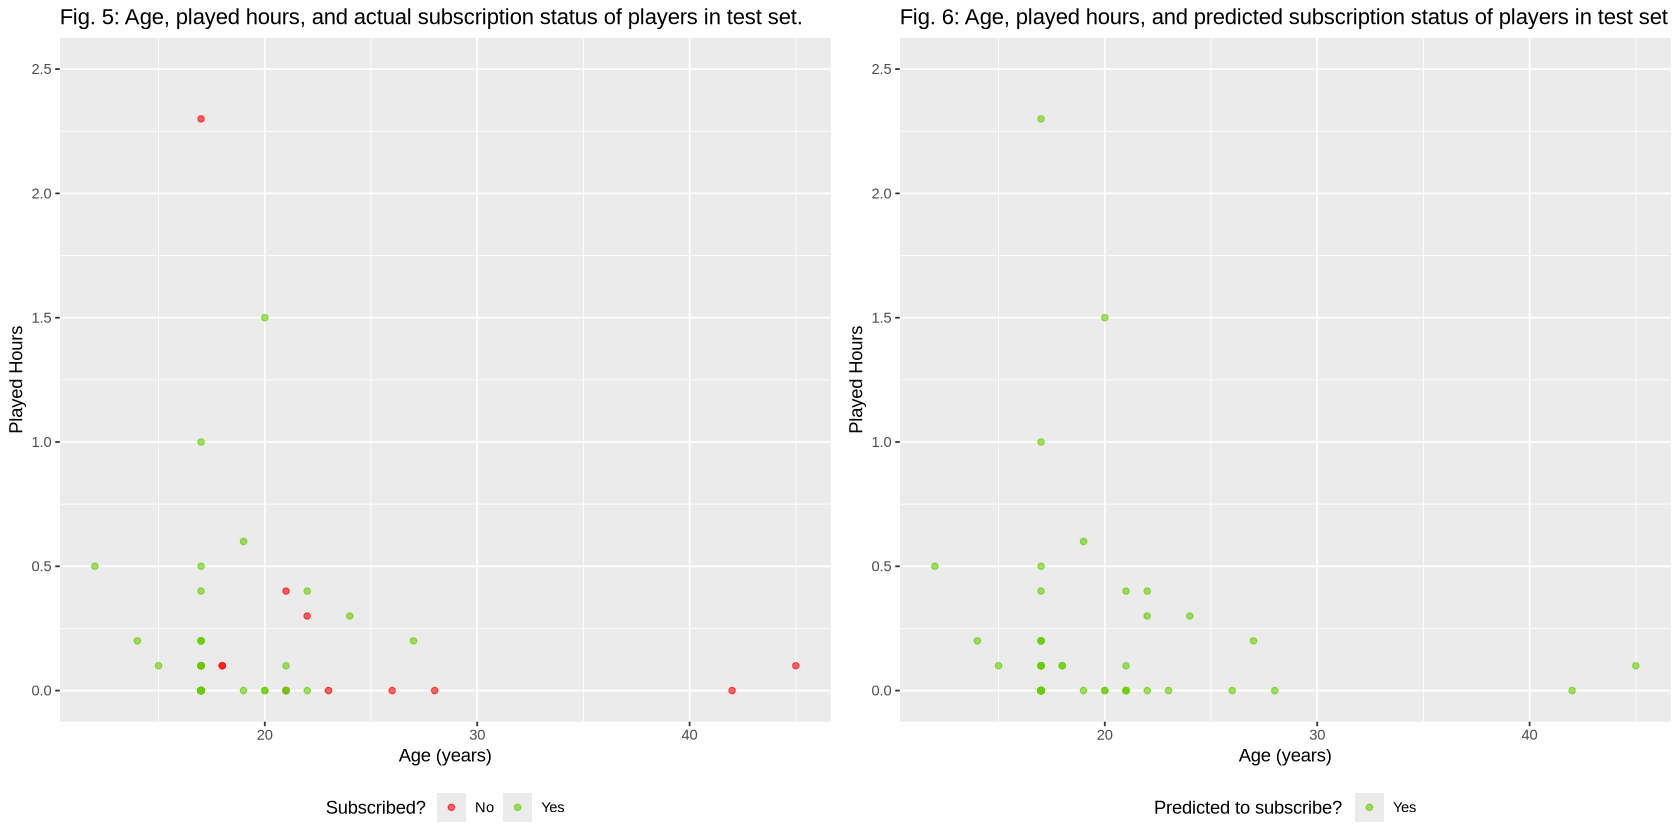

In [41]:
players_best_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = best_k) |>
    set_engine("kknn") |>
    set_mode("classification")

players_fit <- workflow() |>
    add_recipe(players_recipe) |>
    add_model(players_best_spec) |>
    fit(data = players_train)

players_predicted <- players_fit |>
    predict(players_test) |>
    bind_cols(players_test) 

players_plot <- players_predicted |>
    ggplot(aes(x = Age, y = played_hours, color = subscribe)) +
    geom_point(alpha = 0.6) +
    labs(x = "Age (years)", y = "Played Hours", title = "Fig. 5: Age, played hours, and actual subscription status of players in test set.", color = "Subscribed?") +
    ylim(0, 2.5) +
    theme(text = element_text(size = 11), legend.position = "bottom", legend.direction = "horizontal") +
    scale_color_manual(values = c("red", "chartreuse3"))

players_predicted_plot <- players_predicted |>
    ggplot(aes(x = Age, y = played_hours, color = .pred_class)) +
    geom_point(alpha = 0.6) +
    labs(x = "Age (years)", y = "Played Hours", title = "Fig. 6: Age, played hours, and predicted subscription status of players in test set", color = "Predicted to subscribe?") +
    ylim(0, 2.5) +
    theme(text = element_text(size = 11), legend.position = "bottom", legend.direction = "horizontal") +
    scale_color_manual(values = "chartreuse3")

plot_grid(players_plot, players_predicted_plot, ncol = 2)

Model performance metrics were calculated with "Yes" as the positive class for the variable `subscribe`. The model achieved an accuracy of 0.7346939, a perfect recall of 1, and a precision of 0.7346939. The confusion matrix and Fig. 6 indicate that the model predicted every observation as subscribed ("Yes").

In [42]:
players_accuracy <- players_predicted |>
    metrics(truth = subscribe, estimate = .pred_class) |>
    filter(.metric == "accuracy")

players_precision <- players_predicted |>
    precision(truth = subscribe, estimate = .pred_class, event_level = "second")

players_recall <- players_predicted |>
    recall(truth = subscribe, estimate = .pred_class, event_level = "second")

players_conf_mat <- players_predicted |>
    conf_mat(truth = subscribe, estimate = .pred_class)

players_conf_mat
bind_rows(players_accuracy, players_precision, players_recall) |>
    select(-.estimator)

          Truth
Prediction No Yes
       No   0   0
       Yes 13  36

.metric,.estimate
<chr>,<dbl>
accuracy,0.7346939
precision,0.7346939
recall,1.0000000


The accuracy of played might seem solid initially, but it indicates that nearly 3 in every 10 individuals are misclassified, suggesting age and played hours are likely poor predictors of subscription status. The model's perfect recall is a result of predicting "Yes" for every observation, which also explains why the precision matches the accuracy, as the denominators (total number of predictions equals the number of positive predictions) and the numerators (number of true predictions equals number of true positive predictions) are the same. These misleading performance metrics likely stem from class imbalance. With relatively few negatives ("No"), the model produces fewer false positives even when it predicts "Yes" for every observation, inflating accuracy and precision. Consequently, it remains unclear whether age and played hours are inherently poor predictors or if the imbalance is obscuring their true potential. Upsampling the "No" class during pre-processing could help address this issue.

## (4) Discussion:
- summarize what you found
- discuss whether this is what you expected to find?
- discuss what impact could such findings have?
- discuss what future questions could this lead to?